In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import xgboost as xgb
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
import seaborn as sns

In [4]:
# 1. Load dữ liệu đã làm sạch từ bước trước
df = pd.read_csv('../../data/processed/training_data_final.csv', parse_dates=['Datetime'], index_col='Datetime')


In [5]:
# ======================================================
# 2. FEATURE ENGINEERING (Tạo độ trễ - Lag)
# ======================================================
cols = ['Gold', 'Brent', 'Silver', 'Wheat', 'USD index']
target_col = 'Gold'

# Tạo Lag 1 đến Lag 3 (Dùng giá 3 phút trước để đoán giá hiện tại)
for col in cols:
    for lag in [1, 2, 3]:
        df[f'{col}_Lag{lag}'] = df[col].shift(lag)

# Xóa các dòng NaN
df.dropna(inplace=True)

# Xác định Input (X) và Output (y)
feature_cols = [c for c in df.columns if 'Lag' in c]
X = df[feature_cols]
y = df[target_col]

print(f"Kích thước dữ liệu sau xử lý: {df.shape}")

Kích thước dữ liệu sau xử lý: (177859, 20)


In [6]:
# 2. FEATURE ENGINEERING (Tạo đặc trưng nâng cao)
# XGBoost thích nhiều dữ liệu đầu vào để học luật

features = ['Gold', 'Silver', 'Brent', 'Wheat', 'USD index']
target = 'Gold'

# A. Tạo Lag (Dữ liệu quá khứ t-1, t-2)
for col in features:
    df[f'{col}_lag1'] = df[col].shift(1) # Giá 30s trước
    df[f'{col}_lag2'] = df[col].shift(2) # Giá 60s

# B. Tạo Rolling Features (Xu hướng ngắn hạn)
# Trung bình giá Vàng trong 90s qua
df['Gold_MA5'] = df['Gold'].rolling(window=5).mean().shift(1)
# Độ biến động (Standard Deviation) của Vàng trong 150s qua
df['Gold_Vol5'] = df['Gold'].rolling(window=5).std().shift(1)
# C. Xóa các dòng NaN do shift/rolling tạo ra
df.dropna(inplace=True)

In [7]:
# ======================================================
# 3. CHIA TẬP TRAIN/TEST VÀ CHUẨN HÓA (SCALING)
# ======================================================
# XGBoost hoạt động tốt hơn và hội tụ nhanh hơn khi dữ liệu được chuẩn hóa

split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# --- Scale X ---
scaler_X = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# --- Scale y (Bắt buộc để đồng bộ logic Inverse Transform) ---
scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

# XGBoost cần y dạng 1 chiều
y_train_scaled = y_train_scaled.ravel()

print("✅ Đã chuẩn hóa dữ liệu.")

✅ Đã chuẩn hóa dữ liệu.


✅ Huấn luyện xong!


<Figure size 1000x600 with 0 Axes>

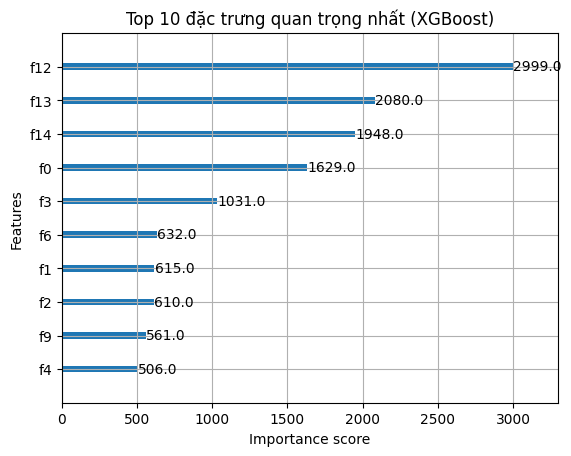

In [8]:
# ======================================================
# 4. HUẤN LUYỆN MÔ HÌNH XGBOOST
# ======================================================
# Khởi tạo mô hình XGB Regressor
model = xgb.XGBRegressor(
    n_estimators=1000,      # Số lượng cây (boosting rounds)
    learning_rate=0.05,     # Tốc độ học (nhỏ giúp tránh overfitting)
    max_depth=6,            # Độ sâu tối đa của cây
    random_state=42,
    n_jobs=-1               # Dùng hết nhân CPU
)

model.fit(X_train_scaled, y_train_scaled)

print("✅ Huấn luyện xong!")

# (Optional) Vẽ biểu đồ mức độ quan trọng của đặc trưng
plt.figure(figsize=(10, 6))
xgb.plot_importance(model, max_num_features=10)
plt.title("Top 10 đặc trưng quan trọng nhất (XGBoost)")
plt.show()

In [9]:
# ======================================================
# 5. DỰ BÁO VÀ LƯU KẾT QUẢ
# ======================================================
# a. Dự báo
y_pred_scaled = model.predict(X_test_scaled)

# b. Inverse Transform (Đưa về giá USD thật)
pred_usd = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))
actual_usd = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1))

# c. Tạo DataFrame kết quả
result_df = pd.DataFrame({
    'Datetime': y_test.index,
    'Actual': actual_usd.flatten(),
    'Predicted': pred_usd.flatten()
})

# d. Lưu file CSV
save_path = '../../results/predictions/XG.csv'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
result_df.to_csv(save_path, index=False)

print(f"\n✅ Đã lưu kết quả (USD) vào: {save_path}")
print(result_df.tail())

# e. Đánh giá nhanh
mse = mean_squared_error(actual_usd, pred_usd)
print(f"\nMSE (USD): {mse:.4f}")


✅ Đã lưu kết quả (USD) vào: ../../results/predictions/XG.csv
                 Datetime   Actual    Predicted
35571 2025-12-18 23:57:00  4357.14  4211.880859
35572 2025-12-18 23:57:10  4358.14  4211.880859
35573 2025-12-18 23:57:20  4359.20  4211.880859
35574 2025-12-18 23:57:30  4359.63  4211.880859
35575 2025-12-18 23:57:40  4359.63  4211.880859

MSE (USD): 4274.1235
